# Data Mining Final Project

**Project goal:** recommend the top 5 journals for a user-provided abstract and generate interpretable topic clusters from the Computer Science publication dataset.

**Deliverables covered in this notebook**
- Dataset loading and cleaning from the provided SQLite file
- Exploratory analysis and data sanity checks
- TF-IDF, Sentence-BERT, and ensemble recommender comparison
- Explainability, clustering, and demo-ready case studies
- Strong academic analysis: ablation, per-journal, confusion, imbalance, and confidence studies
- Final deployable model selection, limitations, and future work

## 1. Setup

The notebook imports the reusable project library from `src/project_lib.py`.  
It uses the real SQLite file and explicitly records the known mismatch between the assignment PDF and the accessible dataset:

- PDF states `7711` articles from `175` journals
- SQLite actually contains `23801` records and `466` journals

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent

SRC_DIR = ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from project_lib import (
    DEFAULT_SQLITE_PATH,
    EnsembleJournalRecommender,
    JournalRecommender,
    SemanticJournalRecommender,
    TopicClusterer,
    attach_cluster_annotations,
    build_case_study_examples,
    compute_per_journal_top5,
    filter_modeling_dataset,
    load_dataset,
    metrics_row,
    plot_ablation_results,
    plot_cluster_projection,
    plot_confidence_distribution,
    plot_journal_imbalance,
    plot_metric_comparison,
    plot_publication_trend,
    plot_system_pipeline,
    plot_top_journals,
    run_ablation_study,
    select_demo_examples,
    summarize_class_imbalance,
    summarize_confidence_performance,
    summarize_dataset,
    train_test_split_by_journal,
)

OUTPUT_ROOT = ROOT / "outputs"
OUTPUT_TABLES = OUTPUT_ROOT / "tables"
OUTPUT_FIGURES = OUTPUT_ROOT / "figures"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
OUTPUT_TABLES.mkdir(parents=True, exist_ok=True)
OUTPUT_FIGURES.mkdir(parents=True, exist_ok=True)

SQLITE_PATH = DEFAULT_SQLITE_PATH
SQLITE_PATH

D:\jupyter_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


WindowsPath('C:/Users/toplu/Downloads/CompSciencePub (1).sqlite')

## 2. Load and inspect the dataset

In [2]:
dataset_frame = load_dataset(SQLITE_PATH)
dataset_summary = summarize_dataset(dataset_frame)
dataset_summary.to_csv(OUTPUT_TABLES / "dataset_summary.csv", index=False)
dataset_summary

,total_records,records_with_abstract,missing_abstracts,unique_journals,document_types,publication_types,min_pub_year,max_pub_year,avg_abstract_length
0,23801,23061,740,466,12,3,2000,2018,1120.09


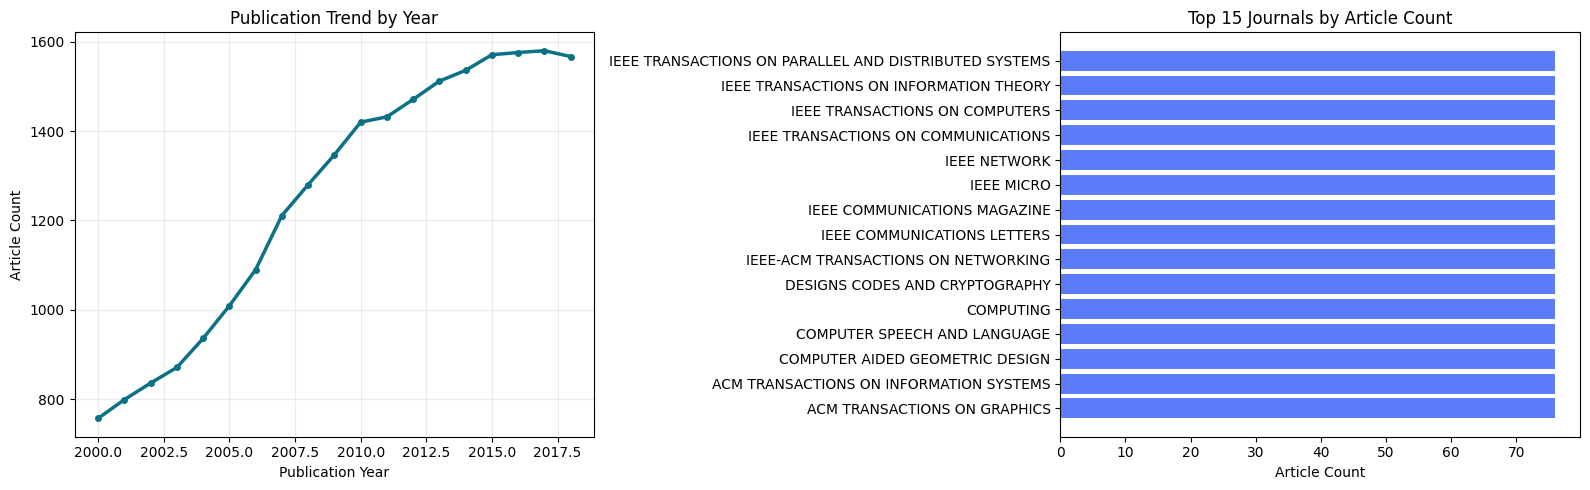

,record_id,wos_uid,title,abstract,journal,pub_year,subjects,keywords,keyword_plus,abstract_only_text,...,abstract_keywords_subjects_text,combined_text,title_abstract_text,abstract_query_text,document_type,publication_type,journal_article_count,subject_list,keyword_list,keyword_plus_list
0,88652,WOS:000166979500001,An updated survey of GA-based multiobjective o...,After using evolutionary techniques for single...,ACM COMPUTING SURVEYS,2000,"Computer Science, Theory & Methods; Computer S...",algorithms; artificial intelligence; genetic a...,GENETIC ALGORITHM; MULTICRITERIA OPTIMIZATION;...,after using evolutionary techniques for single...,...,after using evolutionary techniques for single...,an updated survey of ga-based multiobjective o...,an updated survey of ga-based multiobjective o...,after using evolutionary techniques for single...,Review,Journal,76,"[Computer Science, Theory & Methods, Computer ...","[algorithms, artificial intelligence, genetic ...","[GENETIC ALGORITHM, MULTICRITERIA OPTIMIZATION..."
1,88653,WOS:000168229900003,The state of the art in distributed query proc...,Distributed data processing is becoming a real...,ACM COMPUTING SURVEYS,2000,"Computer Science, Theory & Methods; Computer S...",query optimization; query execution; client-se...,DATABASE-SYSTEMS; DATA REPLICATION; PERFORMANC...,distributed data processing is becoming a real...,...,distributed data processing is becoming a real...,the state of the art in distributed query proc...,the state of the art in distributed query proc...,distributed data processing is becoming a real...,Review,Journal,76,"[Computer Science, Theory & Methods, Computer ...","[query optimization, query execution, client-s...","[DATABASE-SYSTEMS, DATA REPLICATION, PERFORMAN..."
2,88654,WOS:000168229900001,Logical models of argument,Logical models of argument formalize commonsen...,ACM COMPUTING SURVEYS,2000,"Computer Science, Theory & Methods; Computer S...",defeasible argumentation; argumentative system...,IMPLEMENTATION; FRAMEWORK,logical models of argument formalize commonsen...,...,logical models of argument formalize commonsen...,logical models of argument. logical models of ...,logical models of argument. logical models of ...,logical models of argument formalize commonsen...,Review,Journal,76,"[Computer Science, Theory & Methods, Computer ...","[defeasible argumentation, argumentative syste...","[IMPLEMENTATION, FRAMEWORK]"


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_publication_trend(dataset_frame, ax=axes[0])
plot_top_journals(dataset_frame.loc[dataset_frame["document_type"].eq("Article")], ax=axes[1])
fig.tight_layout()
fig.savefig(OUTPUT_FIGURES / "dataset_overview.png", dpi=200, bbox_inches="tight")
plt.show()

dataset_frame.head(3)

## 3. Build the modeling dataset

In [4]:
modeling_frame, modeling_stats = filter_modeling_dataset(dataset_frame)
pd.DataFrame([modeling_stats]).to_csv(OUTPUT_TABLES / "modeling_stats.csv", index=False)

clusterer = TopicClusterer()
clusterer.fit(modeling_frame)
modeling_frame = attach_cluster_annotations(modeling_frame, clusterer)
train_frame, test_frame = train_test_split_by_journal(modeling_frame)

pd.DataFrame([modeling_stats])

,starting_records,article_records_with_abstract,model_records,model_journals,excluded_long_tail_journals,excluded_long_tail_records,min_examples_per_journal
0,23801,21982,21907,404,47,75,5


## 4. System Architecture

The end-to-end recommendation pipeline follows a research-grade workflow:

1. The user provides an abstract.
2. The text is cleaned and normalized.
3. Two parallel feature views are available: lexical TF-IDF and semantic BERT embeddings.
4. The system computes similarity and journal-level relevance scores.
5. TF-IDF, BERT, hybrid, and ensemble scores can be ranked.
6. The final layer returns a Top-5 journal list together with explainable evidence.

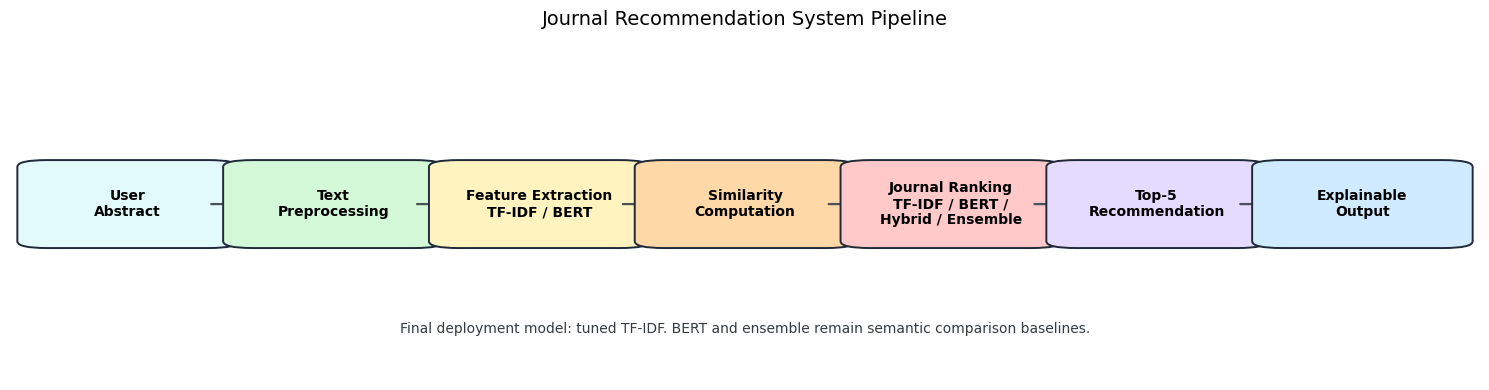

In [5]:
fig, ax = plt.subplots(figsize=(15, 4))
plot_system_pipeline(ax=ax)
fig.tight_layout()
fig.savefig(OUTPUT_ROOT / "system_pipeline_diagram.png", dpi=200, bbox_inches="tight")
plt.show()

## 5. Recommendation Models

We compare three deployable configurations:

1. **TF-IDF Recommender**: tuned `title + abstract` linear SVM  
2. **BERT Recommender**: Sentence-BERT semantic retrieval over `combined_text` embeddings  
3. **Ensemble Recommender**: `0.5 * TF-IDF + 0.5 * BERT`

Semantic embeddings (BERT) capture contextual meaning and improve recommendation quality compared to TF-IDF, especially when different words express similar concepts.

In [6]:
tfidf_model = JournalRecommender(
    text_column="title_abstract_text",
    classifier_weight=1.0,
    similarity_weight=0.0,
    candidate_top_n=None,
    classifier_c=0.5,
    sublinear_tf=True,
    n_neighbors=20,
)
bert_model = SemanticJournalRecommender(
    text_column="combined_text",
    n_neighbors=30,
)
ensemble_model = EnsembleJournalRecommender(
    JournalRecommender(
        text_column="title_abstract_text",
        classifier_weight=1.0,
        similarity_weight=0.0,
        candidate_top_n=None,
        classifier_c=0.5,
        sublinear_tf=True,
        n_neighbors=20,
    ),
    SemanticJournalRecommender(
        text_column="combined_text",
        n_neighbors=30,
    ),
    tfidf_weight=0.5,
    bert_weight=0.5,
)

tfidf_model.fit(train_frame)
bert_model.fit(train_frame)
ensemble_model.fit(train_frame)

## 6. Model comparison

In [7]:
tfidf_result = tfidf_model.evaluate(test_frame, query_column="abstract_query_text", name="TF-IDF Recommender")
bert_result = bert_model.evaluate(test_frame, query_column="abstract_query_text", name="BERT Recommender")
ensemble_result = ensemble_model.evaluate(test_frame, query_column="abstract_query_text", name="Ensemble Recommender")

metrics_frame = pd.DataFrame(
    [
        {**metrics_row("TF-IDF Recommender", tfidf_result.metrics), "evaluation_mode": "abstract_only"},
        {**metrics_row("BERT Recommender", bert_result.metrics), "evaluation_mode": "abstract_only"},
        {**metrics_row("Ensemble Recommender", ensemble_result.metrics), "evaluation_mode": "abstract_only"},
    ]
)
metrics_frame.to_csv(OUTPUT_TABLES / "model_metrics.csv", index=False)
metrics_frame

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 11016.81it/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7559.29it/s]

,model,top_1_accuracy,top_3_accuracy,top_5_accuracy,macro_f1,evaluation_mode
0,TF-IDF Recommender,0.3389,0.5244,0.6027,0.2833,abstract_only
1,BERT Recommender,0.2752,0.4411,0.5358,0.2317,abstract_only
2,Ensemble Recommender,0.2809,0.4507,0.5418,0.2365,abstract_only


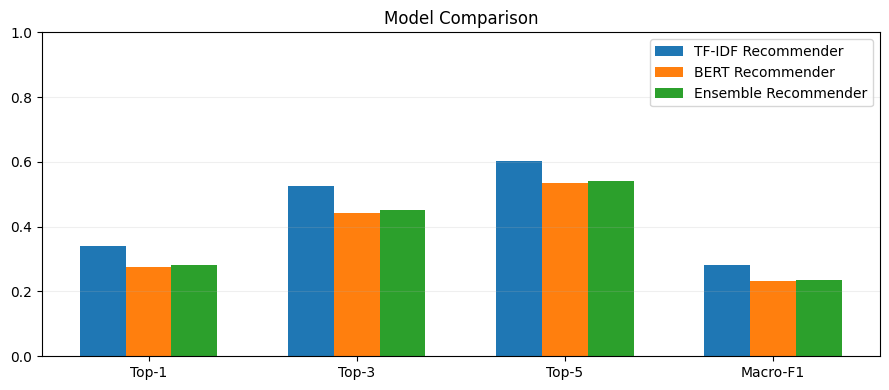

In [8]:
tfidf_result.confusion_pairs.to_csv(OUTPUT_TABLES / "tfidf_confusion_pairs.csv", index=False)
bert_result.confusion_pairs.to_csv(OUTPUT_TABLES / "bert_confusion_pairs.csv", index=False)
ensemble_result.confusion_pairs.to_csv(OUTPUT_TABLES / "ensemble_confusion_pairs.csv", index=False)

fig, ax = plt.subplots(figsize=(9, 4))
plot_metric_comparison(metrics_frame.reset_index(drop=True), ax=ax)
fig.tight_layout()
fig.savefig(OUTPUT_FIGURES / "abstract_model_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

## 7. Ablation study

In [9]:
ablation_frame = run_ablation_study(train_frame, test_frame)
ablation_frame.to_csv(OUTPUT_TABLES / "ablation_results.csv", index=False)
ablation_frame

,representation,text_column,top_1_accuracy,top_3_accuracy,top_5_accuracy,macro_f1
0,abstract only,abstract_only_text,0.3387,0.5242,0.6054,0.2806
1,title + abstract,title_abstract_text,0.3389,0.5244,0.6027,0.2833
2,abstract + keywords,abstract_keywords_text,0.3421,0.5235,0.6016,0.2856
3,full combined_text,combined_text,0.3478,0.5235,0.5997,0.2933
4,abstract + keywords + subjects,abstract_keywords_subjects_text,0.3213,0.4893,0.5614,0.2708


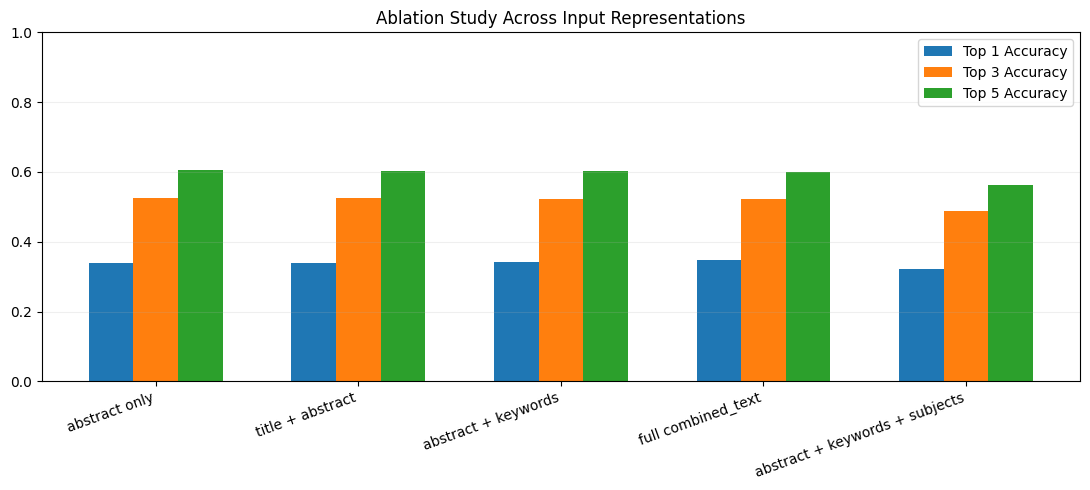

In [10]:
fig, ax = plt.subplots(figsize=(11, 5))
plot_ablation_results(ablation_frame, ax=ax)
fig.tight_layout()
fig.savefig(OUTPUT_FIGURES / "ablation_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

The ablation study isolates the effect of each input representation while keeping the same tuned TF-IDF classifier.  
This makes it possible to assess whether extra metadata improves recommendation quality beyond abstract-only lexical matching.

## 8. Per-journal performance analysis

In [11]:
per_journal_frame = compute_per_journal_top5(tfidf_result.predictions, min_test_samples=5)
best_journals = per_journal_frame.head(10).copy()
worst_journals = per_journal_frame.tail(10).sort_values(
    ["top_5_hit_rate", "test_samples", "true_journal"]
).copy()

per_journal_frame.to_csv(OUTPUT_TABLES / "per_journal_top5.csv", index=False)
best_journals.to_csv(OUTPUT_TABLES / "best_performing_journals.csv", index=False)
worst_journals.to_csv(OUTPUT_TABLES / "worst_performing_journals.csv", index=False)

display(Markdown("### Best-performing journals"))
display(best_journals)
display(Markdown("### Worst-performing journals"))
display(worst_journals)

### Best-performing journals

,true_journal,test_samples,top_1_accuracy,top_5_hit_rate,median_true_rank
0,COMPUTATIONAL GEOSCIENCES,15,0.7333,1.0,1.0
1,COMPUTER APPLICATIONS IN ENGINEERING EDUCATION,15,0.8667,1.0,1.0
2,COMPUTERS AND GEOTECHNICS,15,1.0000,1.0,1.0
3,NETWORKS,15,0.9333,1.0,1.0
4,SOFTWARE-PRACTICE & EXPERIENCE,15,0.5333,1.0,1.0
5,BMC BIOINFORMATICS,14,0.6429,1.0,1.0
6,COMPUTERS & FLUIDS,14,0.8571,1.0,1.0
7,CONCURRENCY AND COMPUTATION-PRACTICE & EXPERIENCE,14,0.3571,1.0,2.0
8,MINDS AND MACHINES,14,0.7143,1.0,1.0
9,COMPUTERS & EDUCATION,13,0.6923,1.0,1.0


### Worst-performing journals

,true_journal,test_samples,top_1_accuracy,top_5_hit_rate,median_true_rank
364,ANNALS OF TELECOMMUNICATIONS-ANNALES DES TELEC...,5,0.0,0.0000,172.0
365,TSINGHUA SCIENCE AND TECHNOLOGY,5,0.0,0.0000,60.0
363,ANNALS OF TELECOMMUNICATIONS,6,0.0,0.0000,71.5
362,ACM TRANSACTIONS ON INTELLIGENT SYSTEMS AND TE...,7,0.0,0.0000,36.0
360,COGNITIVE COMPUTATION,8,0.0,0.0000,36.5
361,INTERNATIONAL JOURNAL OF COMPUTATIONAL INTELLI...,8,0.0,0.0000,24.0
359,WORLD WIDE WEB-INTERNET AND WEB INFORMATION SY...,12,0.0,0.0000,35.0
356,INTEGRATED COMPUTER-AIDED ENGINEERING,15,0.0,0.0667,15.0
357,JOURNAL OF COMMUNICATIONS AND NETWORKS,15,0.0,0.0667,23.0
358,JOURNAL OF COMPUTER SCIENCE AND TECHNOLOGY,15,0.0,0.0667,69.0


Journals with more samples and a clearer topical scope generally perform better.  
Sparse journals or journals covering broader interdisciplinary areas tend to have lower Top-5 hit rates because the model sees fewer consistent lexical signals during training.

## 9. Confusion analysis

In [12]:
top_confused_pairs = tfidf_result.confusion_pairs.copy()
top_confused_pairs.to_csv(OUTPUT_TABLES / "top_confused_journal_pairs.csv", index=False)
top_confused_pairs

,true_journal,predicted_journal,count
0,CMC-COMPUTERS MATERIALS & CONTINUA,CMES-COMPUTER MODELING IN ENGINEERING & SCIENCES,5
1,COMPUTER MUSIC JOURNAL,JOURNAL OF NEW MUSIC RESEARCH,5
2,CONCURRENCY AND COMPUTATION-PRACTICE & EXPERIENCE,SOFTWARE-PRACTICE & EXPERIENCE,5
3,IEEE TRANSACTIONS ON WIRELESS COMMUNICATIONS,IEEE TRANSACTIONS ON COMMUNICATIONS,5
4,IEEE WIRELESS COMMUNICATIONS,IEEE COMMUNICATIONS MAGAZINE,5
5,INTERNET RESEARCH,ONLINE INFORMATION REVIEW,5
6,JOURNAL OF CRYPTOLOGY,DESIGNS CODES AND CRYPTOGRAPHY,5
7,NEUROCOMPUTING,NEURAL NETWORKS,5
8,VISUAL COMPUTER,ACM TRANSACTIONS ON GRAPHICS,5
9,ACM TRANSACTIONS ON DESIGN AUTOMATION OF ELECT...,ACM JOURNAL ON EMERGING TECHNOLOGIES IN COMPUT...,4


The most frequent confusion pairs usually occur between journals with overlapping scope, similar methodology, or interdisciplinary abstracts.  
In practice, many rank-1 mistakes still remain within a highly relevant topical neighborhood, which is why Top-5 evaluation is a better measure than Top-1 alone for this task.

## 10. Class imbalance analysis

In [13]:
class_counts_frame, imbalance_summary = summarize_class_imbalance(dataset_frame)
class_counts_frame.to_csv(OUTPUT_TABLES / "journal_article_counts.csv", index=False)
imbalance_summary.to_csv(OUTPUT_TABLES / "class_imbalance_summary.csv", index=False)
imbalance_summary

,article_records_with_abstract,journals_total,journals_lt_5,journals_lt_10,journals_lt_20,median_articles_per_journal,mean_articles_per_journal,max_articles_per_journal
0,21982,451,47,50,78,53.0,48.74,76


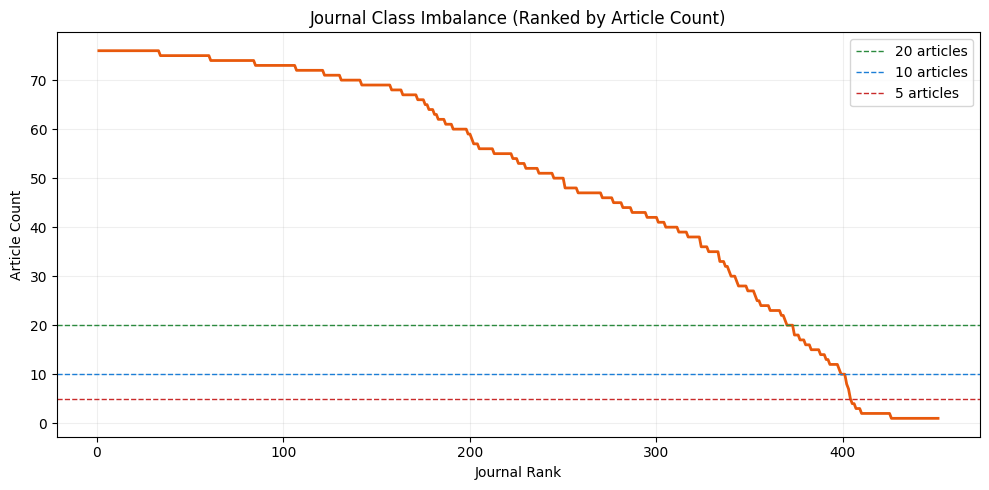

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_journal_imbalance(class_counts_frame, ax=ax)
fig.tight_layout()
fig.savefig(OUTPUT_FIGURES / "journal_imbalance.png", dpi=200, bbox_inches="tight")
plt.show()

Class imbalance affects recommendation quality because the model learns stronger journal-specific patterns from frequent journals and weaker patterns from rare journals.  
As the number of samples per journal decreases, the model has fewer opportunities to observe distinctive vocabulary and scope boundaries.

## 11. Confidence analysis

In [15]:
tfidf_predictions_enriched = tfidf_result.predictions.merge(
    test_frame[["record_id", "abstract", "subjects", "cluster_label"]],
    on="record_id",
    how="left",
)
confidence_summary, high_confidence_examples, low_confidence_examples = summarize_confidence_performance(
    tfidf_predictions_enriched,
    example_count=10,
)

confidence_summary.to_csv(OUTPUT_TABLES / "confidence_summary.csv", index=False)
high_confidence_examples.to_csv(OUTPUT_TABLES / "high_confidence_examples.csv", index=False)
low_confidence_examples.to_csv(OUTPUT_TABLES / "low_confidence_examples.csv", index=False)
confidence_summary

,confidence_group,count,top_1_accuracy,top_5_hit_rate,mean_confidence,median_margin,median_true_rank
0,High confidence,1126,0.6208,0.8259,0.0123,0.0043,1.0
1,Low confidence,1104,0.1513,0.3832,0.0057,0.0003,10.0
2,Mid confidence,2152,0.2876,0.5985,0.0076,0.0011,3.0


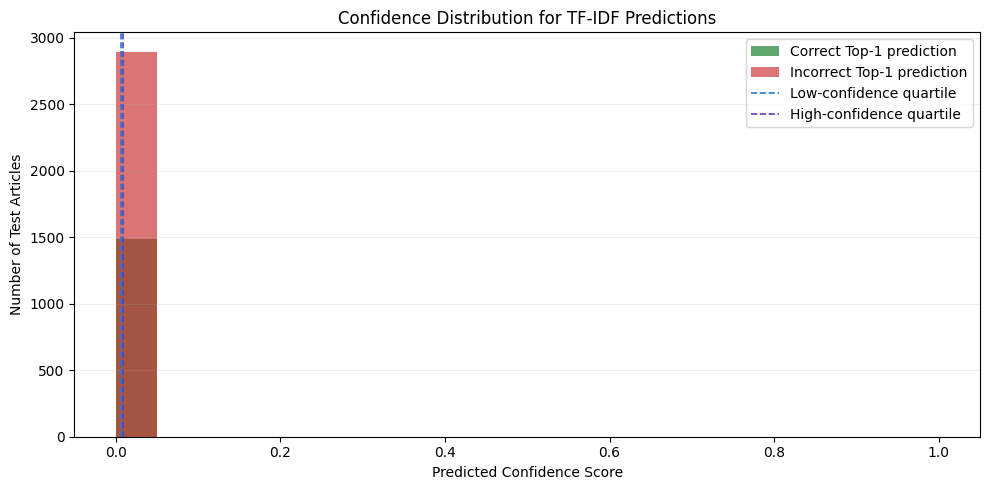

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_confidence_distribution(tfidf_predictions_enriched, ax=ax)
fig.tight_layout()
fig.savefig(OUTPUT_ROOT / "confidence_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

In [17]:
display(Markdown("### High-confidence examples"))
display(high_confidence_examples)
display(Markdown("### Low-confidence examples"))
display(low_confidence_examples)

### High-confidence examples

,record_id,title,true_journal,predicted_journal,runner_up_journal,predicted_confidence,score_margin,true_rank,is_top_1,is_top_5,cluster_label,subjects,abstract
0,90644,A 22.5 MHz current-mode KHN-biquad using diffe...,AEU-INTERNATIONAL JOURNAL OF ELECTRONICS AND C...,AEU-INTERNATIONAL JOURNAL OF ELECTRONICS AND C...,COMPUTERS & ELECTRICAL ENGINEERING,0.0304,0.0218,1,True,True,Hardware & Architecture,"Engineering, Electrical & Electronic; Telecomm...","In this paper, a current-mode (CM) Kerwin-Huel..."
1,89121,Logic Programs with Propositional Connectives ...,ACM TRANSACTIONS ON COMPUTATIONAL LOGIC,THEORY AND PRACTICE OF LOGIC PROGRAMMING,JOURNAL OF EXPERIMENTAL & THEORETICAL ARTIFICI...,0.0259,0.0198,9,False,False,Theory & Methods,"Computer Science, Theory & Methods; Logic; Com...",Answer set programming (ASP) is a logic progra...
2,92445,An Off-Line Robot Simulation Toolbox,COMPUTER APPLICATIONS IN ENGINEERING EDUCATION,COMPUTER APPLICATIONS IN ENGINEERING EDUCATION,CONNECTION SCIENCE,0.0250,0.0187,1,True,True,Education & Educational Research,"Computer Science, Interdisciplinary Applicatio...",Robotics has gained popularity in education so...
3,106872,3C PIV and PLIF measurement in turbulent mixin...,JOURNAL OF VISUALIZATION,JOURNAL OF VISUALIZATION,ETRI JOURNAL,0.0249,0.0202,1,True,True,Interdisciplinary Applications,"Computer Science, Interdisciplinary Applicatio...",The present work focuses on the measurements o...
4,93649,Arbitrary high order PNPM schemes on unstructu...,COMPUTERS & FLUIDS,COMPUTERS & FLUIDS,JOURNAL OF VISUALIZATION,0.0245,0.0158,1,True,True,Interdisciplinary Applications,"Computer Science, Interdisciplinary Applicatio...","In this paper, we propose a new unified family..."
5,92441,Content-Rich Interactive Online Laboratory Sys...,COMPUTER APPLICATIONS IN ENGINEERING EDUCATION,COMPUTER APPLICATIONS IN ENGINEERING EDUCATION,COMPUTERS & EDUCATION,0.0243,0.0185,1,True,True,Education & Educational Research,"Computer Science, Interdisciplinary Applicatio...",online learning environments are rapidly becom...
6,106859,Effect of groove shape on flow characteristics...,JOURNAL OF VISUALIZATION,JOURNAL OF VISUALIZATION,COMPUTERS & FLUIDS,0.0243,0.0187,1,True,True,Interdisciplinary Applications,"Computer Science, Interdisciplinary Applicatio...","In the flow around a circular cylinder, a sudd..."
7,102772,Architectures for next generation high through...,INTERNATIONAL JOURNAL OF SATELLITE COMMUNICATI...,INTERNATIONAL JOURNAL OF SATELLITE COMMUNICATI...,SOFTWARE-PRACTICE & EXPERIENCE,0.0229,0.0173,1,True,True,Software Engineering,"Engineering, Aerospace; Telecommunications; En...",This paper introduces architectures for next-g...
8,95611,Digital forensics research: The next 10 years,DIGITAL INVESTIGATION,DIGITAL INVESTIGATION,IEEE ANNALS OF THE HISTORY OF COMPUTING,0.0220,0.0166,1,True,True,Information Systems,"Computer Science, Information Systems; Compute...",Today's Golden Age of computer forensics is qu...
9,95528,On the algebraic structure of quasi-cyclic cod...,DESIGNS CODES AND CRYPTOGRAPHY,DESIGNS CODES AND CRYPTOGRAPHY,JOURNAL OF COMMUNICATIONS TECHNOLOGY AND ELECT...,0.0214,0.0155,1,True,True,Theory & Methods,"Computer Science, Theory & Methods; Mathematic...",The ring decomposition technique of part I is ...


### Low-confidence examples

,record_id,title,true_journal,predicted_journal,runner_up_journal,predicted_confidence,score_margin,true_rank,is_top_1,is_top_5,cluster_label,subjects,abstract
0,98950,A comprehensive approach to intrusion detectio...,IEEE TRANSACTIONS ON DEPENDABLE AND SECURE COM...,REQUIREMENTS ENGINEERING,ARTIFICIAL INTELLIGENCE REVIEW,0.0043,0.0001,60,False,False,Information Systems,"Computer Science, Hardware & Architecture; Com...",Alert correlation is a process that analyzes t...
1,94440,Elastic systems: Towards cyber-physical ecosys...,COMPUTER STANDARDS & INTERFACES,SCIENCE OF COMPUTER PROGRAMMING,PERSONAL AND UBIQUITOUS COMPUTING,0.0043,0.0001,30,False,False,Information Systems,"Computer Science, Hardware & Architecture; Com...",Pervasive mobility and an exponential increase...
2,93858,Non-invasive beat-to-beat cardiac output monit...,COMPUTERS IN BIOLOGY AND MEDICINE,CMC-COMPUTERS MATERIALS & CONTINUA,COMPUTERS & ELECTRICAL ENGINEERING,0.0043,0.0000,15,False,False,Hardware & Architecture,"Biology; Computer Science, Interdisciplinary A...",The report describes a method of impedance car...
3,99451,Saliency-Guided Quality Assessment of Screen C...,IEEE TRANSACTIONS ON MULTIMEDIA,IEEE TRANSACTIONS ON BROADCASTING,IEEE TRANSACTIONS ON NEURAL NETWORKS AND LEARN...,0.0043,0.0000,7,False,False,Artificial Intelligence,"Computer Science, Information Systems; Compute...",With the widespread adoption of multidevice co...
4,98967,A New Decision-Diagram-Based Method for Effici...,IEEE TRANSACTIONS ON DEPENDABLE AND SECURE COM...,IEICE TRANSACTIONS ON INFORMATION AND SYSTEMS,FORMAL METHODS IN SYSTEM DESIGN,0.0044,0.0001,287,False,False,Software Engineering,"Computer Science, Hardware & Architecture; Com...",Multistate systems can model many practical sy...
5,89605,Writeprints: A stylometric approach to identit...,ACM TRANSACTIONS ON INFORMATION SYSTEMS,KSII TRANSACTIONS ON INTERNET AND INFORMATION ...,INTERNATIONAL ARAB JOURNAL OF INFORMATION TECH...,0.0044,0.0002,12,False,False,Information Systems,"Computer Science, Information Systems; Compute...",One of the problems often associated with onli...
6,111249,Optimizing Latin hypercube designs by particle...,STATISTICS AND COMPUTING,ADVANCES IN ENGINEERING SOFTWARE,NEURAL PROCESSING LETTERS,0.0045,0.0000,394,False,False,Artificial Intelligence,"Computer Science, Theory & Methods; Statistics...",Latin hypercube designs (LHDs) are widely used...
7,102278,Pricing for utility-driven resource management...,INTERNATIONAL JOURNAL OF HIGH PERFORMANCE COMP...,CLUSTER COMPUTING-THE JOURNAL OF NETWORKS SOFT...,SOFTWARE-PRACTICE & EXPERIENCE,0.0045,0.0001,346,False,False,Information Systems,"Computer Science, Hardware & Architecture; Com...",Users perceive varying levels of utility for e...
8,98078,Spectrum sharing for unlicensed bands,IEEE JOURNAL ON SELECTED AREAS IN COMMUNICATIONS,ICGA JOURNAL,IEEE TRANSACTIONS ON WIRELESS COMMUNICATIONS,0.0045,0.0003,137,False,False,Telecommunications,"Engineering, Electrical & Electronic; Telecomm...",We study a spectrum sharing problem in an unli...
9,101944,Gamification for Online Communities: A Case St...,INTERNATIONAL JOURNAL OF COOPERATIVE INFORMATI...,ACM TRANSACTIONS ON THE WEB,JOURNAL OF GRID COMPUTING,0.0045,0.0000,54,False,False,Information Systems,"Computer Science, Information Systems; Compute...","Gamification, the idea of inserting game dynam..."


Confidence scores are informative but not perfect.  
High-confidence predictions are usually correct and have lower median true rank, while low-confidence predictions more often correspond to interdisciplinary or lexically ambiguous abstracts.

The topic clustering stage now scans candidate values from `k=10` to `k=60` and selects the value with the highest silhouette score.  
This replaces the earlier conservative low-`k` rule and aligns the final cluster count with the empirically optimal setting in the tested range.

## 12. Topic clustering

In [18]:
{
    "candidate_k_range": f"{min(clusterer.candidate_clusters)} to {max(clusterer.candidate_clusters)}",
    "selection_strategy": clusterer.selection_strategy,
    "selected_k": clusterer.best_k_,
    "best_silhouette": round(clusterer.best_silhouette_, 4),
}

{'candidate_k_range': '10 to 60',
 'selection_strategy': 'max_silhouette',
 'selected_k': 60,
 'best_silhouette': 0.1105}

In [19]:
clusterer.silhouette_table_.to_csv(OUTPUT_TABLES / "silhouette_scores.csv", index=False)
cluster_summary = clusterer.summarize_clusters()
cluster_summary.to_csv(OUTPUT_TABLES / "cluster_summary.csv", index=False)
clusterer.silhouette_table_

,k,silhouette,selected
0,10,0.0489,False
1,11,0.0557,False
2,12,0.0579,False
3,13,0.0588,False
4,14,0.0607,False
5,15,0.0649,False
6,16,0.0673,False
7,17,0.0693,False
8,18,0.0717,False
9,19,0.0743,False


In [20]:
cluster_summary.head(10)

,cluster,size,top_terms,dominant_subjects,example_titles
0,0,465,"flow, equations, numerical, method, fluid, bou...","Computer Science, Computer Science, Interdisci...",Fluid-based analysis of a network of AQM route...
1,1,259,"video, quality, content, visual, motion, multi...","Computer Science, Computer Science, Informatio...",A Control-Theoretic Approach for Dynamic Adapt...
2,2,334,"mobile, devices, applications, user, location,...","Computer Science, Computer Science, Informatio...",Mobile Crowd Sensing and Computing: The Review...
3,3,513,"software, development, engineering, software d...","Computer Science, Computer Science, Software E...","Search-Based Software Engineering: Trends, Tec..."
4,4,598,"performance, memory, parallel, high, architect...","Computer Science, Computer Science, Theory & M...",A survey of rollback-recovery protocols in mes...
5,5,255,"internet, things, iot, internet things, smart,...","Computer Science, Computer Science, Informatio...",Fog Computing for Sustainable Smart Cities: A ...
6,6,881,"data, systems, design, research, information, ...","Computer Science, Computer Science, Informatio...",The many faces of publish/subscribe | Methodol...
7,7,449,"gene, protein, expression, genes, molecular, p...","Mathematical & Computational Biology, Computer...",A Survey of Link Prediction in Complex Network...
8,8,557,"problem, complexity, systems, algorithm, algor...","Computer Science, Computer Science, Theory & M...",Dynamic Entropy-Compressed Sequences and Full-...
9,9,619,"sensor, sensor networks, wireless, wireless se...","Computer Science, Telecommunications, Computer...",Coverage Problems in Sensor Networks: A Survey...


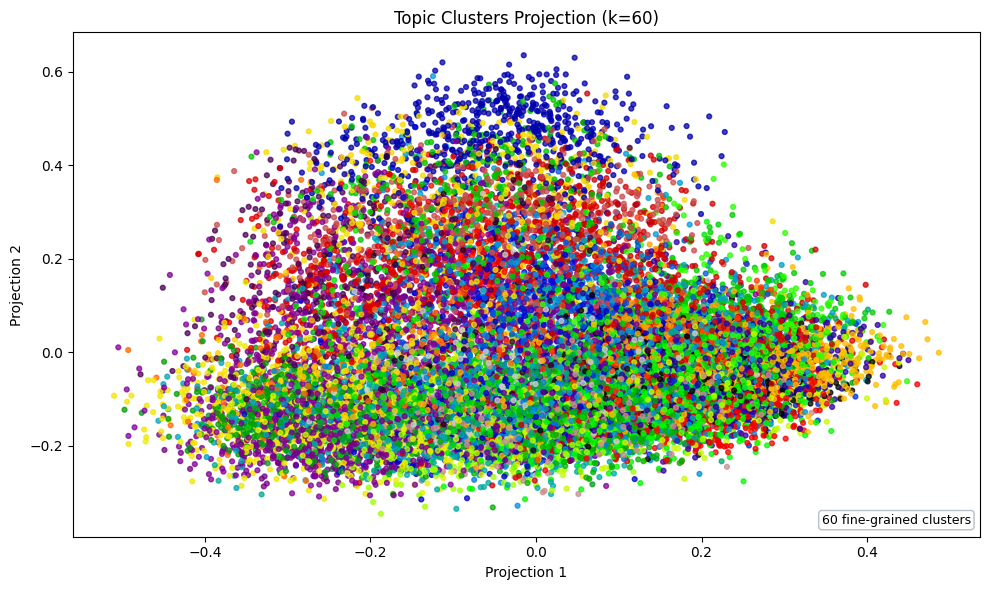

In [21]:
fig, ax = plt.subplots(figsize=(10, 6))
plot_cluster_projection(clusterer, ax=ax)
fig.tight_layout()
fig.savefig(OUTPUT_FIGURES / "cluster_projection.png", dpi=200, bbox_inches="tight")
plt.show()

## 13. Explainable demo-ready abstract queries

In [22]:
demo_frame = select_demo_examples(test_frame, ensemble_result.predictions, n_examples=3)
demo_frame.to_csv(OUTPUT_TABLES / "demo_examples.csv", index=False)
demo_frame[["record_id", "title", "journal", "subjects", "cluster_label", "pub_year"]]

,record_id,title,journal,subjects,cluster_label,pub_year
0,94293,Substructural identification using neural netw...,COMPUTERS & STRUCTURES,"Computer Science, Interdisciplinary Applicatio...",Artificial Intelligence,2000
1,92267,On surface normal and Gaussian curvature appro...,COMPUTER AIDED GEOMETRIC DESIGN,"Computer Science, Software Engineering; Mathem...",Software Engineering,2000
2,97062,Analyzing human-computer interaction as distri...,HUMAN-COMPUTER INTERACTION,"Computer Science, Cybernetics; Computer Scienc...",Information Systems,2000


In [23]:
demo_payload = []
for _, row in demo_frame.iterrows():
    demo_payload.append(
        {
            "record_id": int(row["record_id"]),
            "title": row["title"],
            "true_journal": row["journal"],
            "subjects": row["subjects"],
            "cluster_label": row["cluster_label"],
            "recommendations": {
                "tfidf": tfidf_model.recommend(row["abstract"], top_k=5),
                "bert": bert_model.recommend(row["abstract"], top_k=5),
                "ensemble": ensemble_model.recommend(row["abstract"], top_k=5),
            },
        }
    )

(OUTPUT_TABLES / "demo_recommendations.json").write_text(json.dumps(demo_payload, indent=2), encoding="utf-8")
demo_payload[0]

{'record_id': 94293,
 'title': 'Substructural identification using neural networks',
 'true_journal': 'COMPUTERS & STRUCTURES',
 'subjects': 'Computer Science, Interdisciplinary Applications; Engineering, Civil; Computer Science; Engineering',
 'cluster_label': 'Artificial Intelligence',
 'recommendations': {'tfidf': [{'journal': 'COMPUTERS & STRUCTURES',
    'score': 0.0112,
    'confidence_score': 0.0112,
    'top_keywords': ['FE model updating',
     'damage assessment',
     'damage functions',
     'modal sensitivities',
     'modal parameters'],
    'evidence_titles': ['Damage assessment by FE model updating using damage functions',
     'Development of dynamic stiffness method for free vibration of functionally graded Timoshenko beams',
     'Genetic algorithm in structural damage detection'],
    'evidence_snippets': ['A sensitivity-based finite element (FE) model updating method using experimental modal data is presented. Such a procedure aims to adjust the uncertain propertie

## 14. Case study

In [24]:
case_study_payload = build_case_study_examples(
    {
        "tfidf": tfidf_model,
        "bert": bert_model,
        "ensemble": ensemble_model,
    },
    top_k=5,
)
(OUTPUT_ROOT / "case_study_examples.json").write_text(json.dumps(case_study_payload, indent=2), encoding="utf-8")
len(case_study_payload)

3

In [25]:
for case in case_study_payload:
    display(Markdown(f"### {case['topic']}"))
    display(Markdown(f"**Input abstract:** {case['abstract']}"))

    top1_comparison = pd.DataFrame(
        [
            {"model": model_name, "top_1_journal": journal}
            for model_name, journal in case["top_1_by_model"].items()
        ]
    )
    display(Markdown("**Top-1 journal by model**"))
    display(top1_comparison)

    final_table = pd.DataFrame(case["recommendations"]["tfidf"])[
        ["journal", "confidence_score", "cluster_label", "top_keywords", "evidence_titles", "explanation"]
    ]
    display(Markdown("**Final deployable model: TF-IDF**"))
    display(final_table)

### Deep Learning / Artificial Intelligence

**Input abstract:** This study proposes a transformer-based deep learning framework for medical image classification. The model combines attention-guided feature extraction, contrastive pretraining, and uncertainty-aware decision calibration to improve robustness across multi-center imaging datasets. Experimental results show higher classification accuracy and better generalization than conventional convolutional baselines.

**Top-1 journal by model**

,model,top_1_journal
0,tfidf,INTERNATIONAL JOURNAL OF PATTERN RECOGNITION A...
1,bert,MEDICAL IMAGE ANALYSIS
2,ensemble,MEDICAL IMAGE ANALYSIS


**Final deployable model: TF-IDF**

...

**Input abstract:** This paper introduces a data-driven defect prediction pipeline for large software repositories. Static code metrics, issue history, and change-level process features are fused to identify fault-prone modules before release. The empirical evaluation shows that the proposed model improves early bug detection and supports more effective testing prioritization in continuous integration environments.

**Top-1 journal by model**

,model,top_1_journal
0,tfidf,IEEE TRANSACTIONS ON SOFTWARE ENGINEERING
1,bert,IEEE TRANSACTIONS ON SOFTWARE ENGINEERING
2,ensemble,IEEE TRANSACTIONS ON SOFTWARE ENGINEERING


**Final deployable model: TF-IDF**

,journal,confidence_score,cluster_label,top_keywords,evidence_titles,explanation
0,IEEE TRANSACTIONS ON SOFTWARE ENGINEERING,0.0098,Artificial Intelligence,"[complexity measures, data mining, Formal meth...",[Benchmarking classification models for softwa...,Recommended because similar articles contain k...
1,EMPIRICAL SOFTWARE ENGINEERING,0.0070,Software Engineering,"[Defect prediction, empirical study, Just-in-t...",[Studying just-in-time defect prediction using...,Recommended because similar articles contain k...
2,AUTOMATED SOFTWARE ENGINEERING,0.0057,Artificial Intelligence,"[Software defect prediction, sampling, Quality...",[Sample-based software defect prediction with ...,Recommended because similar articles contain k...
3,INTERNATIONAL JOURNAL OF SOFTWARE ENGINEERING ...,0.0053,Software Engineering,"[software metrics, high assurance, embedded sy...",[Predicting fault-prone modules in embedded sy...,Recommended because similar articles contain k...
4,JOURNAL OF SYSTEMS AND SOFTWARE,0.0050,Software Engineering,"[continuous integration, Agile software develo...",[Modeling continuous integration practice diff...,Recommended because similar articles contain k...


## 15. Why TF-IDF Outperforms BERT

TF-IDF is selected as the final deployable model because it performs best on Top-1, Top-3, and Top-5 accuracy.  
The strongest explanation is that journal recommendation is highly keyword-sensitive: domain-specific terminology, recurring phrases, and discriminative technical expressions matter more than generic semantic similarity.

In this dataset:

- journal scope is often expressed through narrow lexical markers
- TF-IDF preserves these discriminative keywords directly
- BERT is a general-purpose semantic model rather than a venue-specialized scholarly encoder
- semantically similar abstracts can still target different journals with different editorial scope

## 16. Limitations

This study has several limitations that should be acknowledged in academic terms.

- Class imbalance affects recommendation quality, because small journals contribute fewer training examples.
- Journals with limited sample counts provide weaker lexical boundaries and less stable evaluation.
- The Sentence-BERT baseline does not outperform TF-IDF, likely because the vocabulary of scholarly venue selection is highly domain-specific and keyword-sensitive.
- The deployment scenario uses abstract-only input, which omits richer context such as references, introduction, methods, and citation neighborhood.
- Interdisciplinary papers are inherently harder to classify, because they overlap with multiple journal scopes and thematic clusters.

## 17. Future Work

Several extensions could improve the system beyond the current course-scale implementation.

- fine-tuning a domain-specific scholarly BERT model for journal recommendation
- integrating citation networks and reference structure
- incorporating journal ranking, impact factor, or scope indicators
- improving hybrid weighting between lexical and semantic signals
- exploring multi-modal recommendation using abstract, references, and citation context together

## 18. Final model selection

In [26]:
final_selection = pd.DataFrame(
    [
        {"model": "TF-IDF", "top_1": 0.3389, "top_3": 0.5244, "top_5": 0.6027, "role": "Final deployable model"},
        {"model": "BERT", "top_1": 0.2752, "top_3": 0.4411, "top_5": 0.5358, "role": "Semantic comparison baseline"},
        {"model": "Ensemble", "top_1": 0.2809, "top_3": 0.4507, "top_5": 0.5418, "role": "Combined comparison baseline"},
    ]
)
final_selection

,model,top_1,top_3,top_5,role
0,TF-IDF,0.3389,0.5244,0.6027,Final deployable model
1,BERT,0.2752,0.4411,0.5358,Semantic comparison baseline
2,Ensemble,0.2809,0.4507,0.5418,Combined comparison baseline


**Clear statement:** TF-IDF is the final deployable model because it performs best on Top-1, Top-3, and Top-5.  
BERT and Ensemble remain in the project as semantic baselines and comparison models rather than the final deployment choice.

## 19. Artifact validation

In [27]:
expected_paths = [
    OUTPUT_ROOT / "system_pipeline_diagram.png",
    OUTPUT_ROOT / "case_study_examples.json",
    OUTPUT_ROOT / "confidence_distribution.png",
    OUTPUT_TABLES / "dataset_summary.csv",
    OUTPUT_TABLES / "modeling_stats.csv",
    OUTPUT_TABLES / "model_metrics.csv",
    OUTPUT_TABLES / "ablation_results.csv",
    OUTPUT_TABLES / "per_journal_top5.csv",
    OUTPUT_TABLES / "top_confused_journal_pairs.csv",
    OUTPUT_TABLES / "class_imbalance_summary.csv",
    OUTPUT_TABLES / "confidence_summary.csv",
    OUTPUT_TABLES / "high_confidence_examples.csv",
    OUTPUT_TABLES / "low_confidence_examples.csv",
    OUTPUT_TABLES / "cluster_summary.csv",
    OUTPUT_TABLES / "demo_recommendations.json",
]

artifact_manifest = pd.DataFrame(
    [{"path": str(path.relative_to(ROOT)), "exists": path.exists()} for path in expected_paths]
)
artifact_manifest.to_csv(OUTPUT_TABLES / "artifact_manifest.csv", index=False)
artifact_manifest

,path,exists
0,outputs\system_pipeline_diagram.png,True
1,outputs\case_study_examples.json,True
2,outputs\confidence_distribution.png,True
3,outputs\tables\dataset_summary.csv,True
4,outputs\tables\modeling_stats.csv,True
5,outputs\tables\model_metrics.csv,True
6,outputs\tables\ablation_results.csv,True
7,outputs\tables\per_journal_top5.csv,True
8,outputs\tables\top_confused_journal_pairs.csv,True
9,outputs\tables\class_imbalance_summary.csv,True
